# Algoritma Machine Learning untuk Deteksi Spoiler pada Review Buku di Platform Goodreads (Di Run menggunakan VS Code)

Dataset ini digunakan untuk melatih dan mengevaluasi model Machine Learning dalam mendeteksi spoiler pada review buku Goodreads berbahasa Indonesia.

Input -> `review_preprocessed.csv` (hasil preprocessing)

Kolom yang dipakai -> `review_text_stem`, `spoiler_label`

Alur notebook:

Load data -> eksplorasi -> train-test split -> tuning SVM -> tuning random forest -> tuning xgboost -> perbandingan -> visualisasi paper

## 1. Instalasi Dependensi

Catatan perubahan: imbalanced-learn tidak dipakai karena smote tidak cocok untuk sparse matrix tfidf.
handling imbalance dilakukan via class_weight dan scale_pos_weight langsung di fungsi loss.

In [3]:
# install semua library yang dibutuhkan
# scikit-learn: library utama ML, sudah include SVM, Random Forest, Pipeline, dan GridSearchCV
# xgboost: implementasi gradient boosting yang dioptimasi
# pandas, numpy: manipulasi data dan operasi numerik
# matplotlib, seaborn: visualisasi 

!pip install scikit-learn xgboost pandas numpy matplotlib seaborn

## 2. Import Library dan Konfigurasi

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import time 

from sklearn.feature_extraction.text import TfidfVectorizer # untuk mengubah teks menjadi angka
from sklearn.pipeline import Pipeline # untuk menggabungkan TF-IDF + model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold # untuk membagi data dan mencari hyperparameter terbaik

# import model-model machine learning yang akan digunakan
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,    # laporan lengkap precision, recall, f1 per kelas
    confusion_matrix,         # tabel perbandingan prediksi vs aktual
    roc_auc_score,            # skor AUC-ROC, metrik utama
    precision_score,          # dari semua yang diprediksi positif, berapa yang benar
    recall_score,             # dari semua yang benar positif, berapa yang berhasil terdeteksi
    f1_score,                 # rata-rata harmonis antara precision dan recall
    ConfusionMatrixDisplay    # untuk menampilkan confusion matrix dalam bentuk visual
)
from xgboost import XGBClassifier

# from google.colab import drive
# drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# path input
# INPUT_CSV = '/content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv'
INPUT_CSV = 'review_preprocessed.csv'
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# konstanta global
RANDOM_SEED = 42 # seed untuk reproducibility
TEST_SIZE = 0.2 # 80% train, 20% test

## 3. Load dan Eksplorasi Data

In [5]:
# load data hasil preprocessing
# encoding='utf-8-sig' menangani karakter BOM yang kadang muncul di file Windows
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

# informasi dasar tentang dataset
print(f"total baris: {len(df)}")
print(f"total kolom: {len(df.columns)}")
print(f"kolom: {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\nmissing values pada kolom yang dipakai")
print(df[["review_text_stem", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
# reset_index(drop=True) biar index kembali rapi dari 0
df = df.dropna(subset=["review_text_stem", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah drop missing: {len(df)} baris")

total baris: 11267
total kolom: 3
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values pada kolom yang dipakai
review_text_stem    0
spoiler_label       0
dtype: int64

setelah drop missing: 11267 baris


In [6]:
# distribusi label dan perhitungan imbalance ratio (berapa review spoiler vs non-spoiler)
label_counts = df["spoiler_label"].value_counts()
label_pct = df["spoiler_label"].value_counts(normalize=True) * 100

print("distribusi label")
print()
# gabungkan jumlah dan persentase ke satu tabel yang mudah dibaca
dist_df = pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : label_pct.round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"})
print(dist_df)

# hitung imbalance ratio, seberapa jauh ketimpangan antara dua kelas
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler # angka ini nanti dipakai di XGBoost

print(f"\nimbalance ratio (non-spoiler / spoiler): {imbalance_ratio:.2f}")
print(f"untuk setiap 1 spoiler, ada {imbalance_ratio:.1f} non-spoiler")

distribusi label

                 jumlah  persen
spoiler_label                  
non-spoiler (0)   10281   91.25
spoiler (1)         986    8.75

imbalance ratio (non-spoiler / spoiler): 10.43
untuk setiap 1 spoiler, ada 10.4 non-spoiler


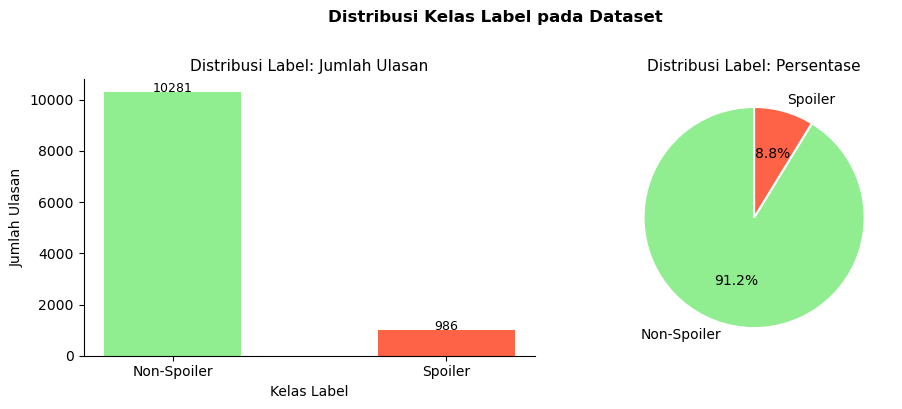

In [7]:
# visualisasi distribusi label (bar chart dan pie chart)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

COLORS = ["lightgreen", "tomato"] 

# bar chart
axes[0].bar(["Non-Spoiler", "Spoiler"], [n_nonspoiler, n_spoiler], color=COLORS, width=0.5)
axes[0].set_title("Distribusi Label: Jumlah Ulasan", fontsize=11)
axes[0].set_ylabel("Jumlah Ulasan")
axes[0].set_xlabel("Kelas Label")
axes[0].spines[["top","right"]].set_visible(False)
for i, v in enumerate([n_nonspoiler, n_spoiler]):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=9)

# pie chart
axes[1].pie(
    [n_nonspoiler, n_spoiler],
    labels=["Non-Spoiler", "Spoiler"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Distribusi Label: Persentase", fontsize=11)

plt.suptitle("Distribusi Kelas Label pada Dataset", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
# hitung panjang teks (dalam jumlah kata/token) per review
# panjang teks bisa jadi sinyal, spoiler mungkin cenderung lebih panjang
df["text_len"] = df["review_text_stem"].apply(lambda x: len(str(x).split()))

# tampilkan statistik deskriptif panjang teks, dikelompokkan berdasarkan label
print("statistik panjang teks (jumlah token) per label")
print()
print(df.groupby("spoiler_label")["text_len"].describe().round(2).rename(index={0: "non-spoiler", 1: "spoiler"}))

statistik panjang teks (jumlah token) per label

                 count   mean    std  min   25%   50%    75%     max
spoiler_label                                                       
non-spoiler    10281.0  63.05  70.06  1.0  18.0  39.0   83.0  1149.0
spoiler          986.0  85.16  93.81  2.0  30.0  60.0  115.0  1162.0


## 4. Persiapan Data & Train-Test Split

Catatan perubahan: tfidf tidak di-fit di sini. tfidf dimasukkan ke dalam pipeline bersama setiap algoritma supaya saat gridsearchcv berjalan, tfidf di-fit ulang hanya pada data training di setiap fold. jika tfidf di-fit di luar, vocabulary sudah terbentuk dari semua train data sebelum cross-validation dimulai (data leakage).

In [9]:
# persiapan data
# X (fitur/input) dan y (label/target)
# .astype(str) memastikan tidak ada tipe data campuran yang bisa menyebabkan error
# X berisi raw text, bukan matriks TF-IDF
# TF-IDF sekarang ada di dalam Pipeline setiap model
X = df["review_text_stem"].astype(str).tolist()
y = df["spoiler_label"].astype(int)

print(f"jumlah sampel: {len(X)}")
print(f"distribusi y: {dict(y.value_counts().sort_index())}")

jumlah sampel: 11267
distribusi y: {0: 10281, 1: 986}


In [10]:
# split data: 80% train, 20% test
# stratify=y memastikan proporsi label sama di train dan test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# hitung imbalance ratio untuk scale_pos_weight xgboost nanti
n_nonspoiler = (y_train == 0).sum()
n_spoiler = (y_train == 1).sum()
imbalance_ratio = n_nonspoiler / n_spoiler

print(f"train set: {len(X_train_raw)} sampel")
print(f"test set: {len(X_test_raw)} sampel")
print(f"spoiler train: {n_spoiler}")
print(f"non-spoiler train: {n_nonspoiler}")
print(f"imbalance ratio: {imbalance_ratio:.2f} (dipakai untuk scale_pos_weight xgboost)")

train set: 9013 sampel
test set: 2254 sampel
spoiler train: 789
non-spoiler train: 8224
imbalance ratio: 10.42 (dipakai untuk scale_pos_weight xgboost)


## 5. Fungsi Evaluasi 

metrik yang dipakai (bukan akurasi):
- precision spoiler -> dari semua prediksi spoiler, berapa yang benar?
- recall spoiler -> dari semua spoiler yang ada, berapa yang terdeteksi?
- f1 spoiler -> rata-rata harmonis precision dan recall
- auc-roc -> kemampuan diskriminasi model di semua threshold, metrik utama

In [11]:
# fungsi evaluate_model: cetak classification report dan auc-roc, kembalikan dict metrik
# parameter
# model_name: nama model (string), untuk label output
# y_true: label aktual dari data test (ground truth)
# y_pred: prediksi model (0 atau 1)
# y_score: skor probabilitas atau decision function untuk kelas positif.
#          dipakai untuk menghitung AUC-ROC yang membutuhkan skor kontinu, bukan prediksi biner.

def evaluate_model(model_name, y_true, y_pred, y_score): 
  print(f"Hasil Evaluasi {model_name}")
  # classification report: precision, recall, f1 untuk setiap kelas dan rata-ratanya
  print("\nClassification Report:")
  print(classification_report(
    y_true, y_pred,
    target_names=["non-spoiler (0)", "spoiler (1)"],
    digits=4
  ))
  # hitung AUC-ROC menggunakan skor kontinu (bukan prediksi biner)
  auc = roc_auc_score(y_true, y_score)
  print(f"AUC-ROC: {auc:.4f}")

  # kembalikan semua metrik dalam bentuk dictionary untuk perbandingan nanti
  return {
    "model"       : model_name,
    "precision_0" : precision_score(y_true, y_pred, pos_label=0), # precision kelas non-spoiler
    "precision_1" : precision_score(y_true, y_pred, pos_label=1), # precision kelas spoiler
    "recall_0"    : recall_score(y_true, y_pred, pos_label=0),    # recall kelas non-spoiler
    "recall_1"    : recall_score(y_true, y_pred, pos_label=1),    # recall kelas spoiler
    "f1_0"        : f1_score(y_true, y_pred, pos_label=0),        # f1 kelas non-spoiler
    "f1_1"        : f1_score(y_true, y_pred, pos_label=1),        # f1 kelas spoiler
    "f1_macro"    : f1_score(y_true, y_pred, average="macro"),    # rata-rata f1 dua kelas (tanpa pembobotan)
    "auc_roc"     : auc,
  }


def plot_confusion_matrix(model_name, y_true, y_pred, ax):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=["non-spoiler", "spoiler"]
  )
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(model_name, fontweight="bold")

# inisialisasi dictionary untuk menyimpan hasil semua model
results = {} # menyimpan metrik evaluasi
predictions = {} # menyimpan prediksi untuk confusion matrix

## 6. Algoritma SVM (Support Vector Machine)

SVM mencari hyperplane yang memaksimalkan margin antara dua kelas. untuk teks tfidf berdimensi tinggi, kernel linear adalah pilihan standar karena data sudah
cenderung linearly separable di ruang berdimensi tinggi.

Untuk handling imbalance -> class_weight="balanced": bobot kelas dihitung otomatis sebagai total_sampel / (jumlah_kelas x jumlah_sampel_kelas), sehingga kesalahan pada spoiler mendapat penalti lebih besar saat training.

In [12]:
# inisialisasi stratified k-fold untuk cross-validation
# n_splits=5 -> data dibagi 5 bagian, model dilatih 5 kali
# shuffle=True -> data diacak sebelum dibagi (dengan seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("tuning SVM...")
t0 = time.time()

# pipeline: tfidf di dalam pipeline supaya di-fit ulang di setiap fold gridsearchcv
# mencegah data leakage antar fold
svm_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf",   LinearSVC(class_weight="balanced", max_iter=3000, random_state=RANDOM_SEED))
])

# parameter grid: kombinasi tfidf dan hyperparameter svm yang akan dicoba
# total: 2 x 2 x 6 = 24 kombinasi x 5 fold = 120 kali fitting
svm_params = {
  "tfidf__max_features" : [30000, 50000],
  "tfidf__ngram_range"  : [(1, 1), (1, 2)],
  "clf__C"              : [0.001, 0.01, 0.1, 1, 10, 100]
}

# GridSearchCV buat coba semua kombinasi parameter dan pilih yang terbaik
svm_grid = GridSearchCV(
  svm_pipeline,
  svm_params,
  cv=cv,
  scoring="roc_auc", # pilih parameter terbaik berdasarkan AUC-ROC, bukan akuras
  n_jobs=-1,         # pakai semua CPU core
  verbose=1
)
# fit menerima raw text (X_train_raw), bukan matriks TF-IDF
svm_grid.fit(X_train_raw, y_train) # mulai training dan tuning

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {svm_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {svm_grid.best_score_:.4f}")

tuning SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

waktu tuning: 105.2 detik
parameter terbaik: {'clf__C': 0.01, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
AUC-ROC CV terbaik: 0.7241


In [13]:
# ambil pipeline terbaik hasil gridsearchcv
best_svm = svm_grid.best_estimator_

# predict label dan decision score di test set
svm_pred = best_svm.predict(X_test_raw)

# linearsvc tidak punya predict_proba, gunakan decision_function (jarak ke hyperplane)
# nilainya kontinu dan bisa dipakai untuk menghitung auc-roc
svm_score = best_svm.decision_function(X_test_raw)

results["SVM"] = evaluate_model("SVM (Linear)", y_test, svm_pred, svm_score)
predictions["SVM"] = svm_pred

Hasil Evaluasi SVM (Linear)

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9464    0.8065    0.8709      2057
    spoiler (1)     0.2056    0.5228    0.2951       197

       accuracy                         0.7817      2254
      macro avg     0.5760    0.6647    0.5830      2254
   weighted avg     0.8816    0.7817    0.8205      2254

AUC-ROC: 0.7441


## 7. Algoritma Random Forest

Random Forest adalah ensemble dari banyak decision tree yang dilatih secara independen. Setiap tree dilatih pada subset data berbeda (bootstrap sampling) dan hanya melihat subset fitur acak di setiap split. prediksi final adalah majority vote semua tree.

Untuk handling imbalance -> class_weight="balanced" 

In [14]:
print("tuning Random Forest...")
t0 = time.time()

rf_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf",   RandomForestClassifier(class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1))
])

# min_samples_leaf memaksa pohon tidak terlalu spesifik ke data latih, mengurangi overfitting
# log2 di max_features: alternatif sqrt, sering lebih baik untuk fitur sangat banyak
# total: 1x1x1x3x3x2 = 18 kombinasi x 5 fold = 90 kali fitting
rf_params = {
  "tfidf__max_features"   : [50000],         # tetapkan satu nilai
  "tfidf__ngram_range"    : [(1, 2)],        # tetapkan satu nilai
  "clf__n_estimators"     : [200],           # tetapkan satu nilai
  "clf__max_depth"        : [10, 20, None],  # tetap tiga nilai
  "clf__min_samples_leaf" : [1, 5, 10],      # tetap tiga nilai
  "clf__max_features"     : ["sqrt", "log2"] # tetap dua nilai
}

# GridSearch untuk menemukan kombinasi hyperparameter terbaik
rf_grid = GridSearchCV(
  rf_pipeline,
  rf_params,
  cv=cv,
  scoring="roc_auc",
  n_jobs=-1,
  verbose=1
)
rf_grid.fit(X_train_raw, y_train) # training + tuning

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {rf_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {rf_grid.best_score_:.4f}")

tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

waktu tuning: 275.6 detik
parameter terbaik: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
AUC-ROC CV terbaik: 0.7163


In [15]:
# evaluasi Random Forest di test set
best_rf = rf_grid.best_estimator_

rf_pred  = best_rf.predict(X_test_raw)
rf_score = best_rf.predict_proba(X_test_raw)[:, 1] # Random Forest punya predict_proba, ambil probabilitas kelas positif (kolom 1)

results["RF"] = evaluate_model("Random Forest", y_test, rf_pred, rf_score)
predictions["RF"] = rf_pred

Hasil Evaluasi Random Forest

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9184    0.9844    0.9503      2057
    spoiler (1)     0.3469    0.0863    0.1382       197

       accuracy                         0.9059      2254
      macro avg     0.6327    0.5354    0.5442      2254
   weighted avg     0.8684    0.9059    0.8793      2254

AUC-ROC: 0.7298


## 8. Algoritma XGBoost

XGBoost adalah implementasi gradient boosting yang dioptimasi. berbeda dengan random forest yang membangun tree secara paralel, gradient boosting membangun tree secara sekuensial: setiap tree baru dilatih untuk memperbaiki kesalahan tree sebelumnya.

untuk handling imbalance -> scale_pos_weight: memberi bobot lebih pada kelas positif (spoiler).

In [16]:
from sklearn.model_selection import RandomizedSearchCV

print("tuning XGBoost...")
t0 = time.time()

xgb_pipeline = Pipeline([
  ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
  ("clf", XGBClassifier(eval_metric="auc", random_state=RANDOM_SEED, n_jobs=-1, verbosity=0))
])

# colsample_bytree: proporsi fitur yang dipakai tiap pohon
# penting untuk tfidf berdimensi tinggi, mirip max_features di random forest
# scale_pos_weight ikut di-tune, tidak hardcode ke imbalance_ratio
# randomizedsearchcv hanya coba 20 kombinasi acak dari total ruang yang sangat besar
xgb_params = {
  "tfidf__max_features"   : [30000, 50000],
  "tfidf__ngram_range"    : [(1, 1), (1, 2)],
  "clf__n_estimators"     : [100, 200, 300],
  "clf__max_depth"        : [3, 6, 9],
  "clf__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
  "clf__subsample"        : [0.7, 0.8, 1.0],
  "clf__colsample_bytree" : [0.3, 0.5, 0.7, 1.0],
  "clf__scale_pos_weight" : [5, imbalance_ratio, 15]
}

xgb_grid = RandomizedSearchCV(
  xgb_pipeline, xgb_params,
  n_iter=20,                 
  cv=cv, scoring="roc_auc",
  n_jobs=-1,
  random_state=RANDOM_SEED,   
  verbose=1
)
xgb_grid.fit(X_train_raw, y_train)

print(f"\nwaktu tuning: {time.time() - t0:.1f} detik")
print(f"parameter terbaik: {xgb_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {xgb_grid.best_score_:.4f}")

tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



waktu tuning: 2116.6 detik
parameter terbaik: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 50000, 'clf__subsample': 0.7, 'clf__scale_pos_weight': 5, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
AUC-ROC CV terbaik: 0.6980


In [17]:
# evaluasi XGBoost di test set
best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test_raw)
xgb_score = best_xgb.predict_proba(X_test_raw)[:, 1] # probabilitas kelas spoiler

results["XGBoost"] = evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)
predictions["XGBoost"] = xgb_pred

Hasil Evaluasi XGBoost

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9192    0.9737    0.9457      2057
    spoiler (1)     0.2800    0.1066    0.1544       197

       accuracy                         0.8980      2254
      macro avg     0.5996    0.5402    0.5501      2254
   weighted avg     0.8634    0.8980    0.8765      2254

AUC-ROC: 0.6711


## 9. Perbandingan Ketiga Algoritma

Perbandingan difokuskan pada:
- AUC-ROC sebagai metrik utama untuk mengukur kemampuan diskriminasi model
- F1-score kelas spoiler (1) sebagai indikator utama keberhasilan deteksi spoiler
- Confusion matrix untuk menganalisis pola kesalahan dari masing-masing model

In [18]:
# konversi dictionary results menjadi DataFrame untuk perbandingan tabel
# .T untuk transpose: model jadi baris, metrik jadi kolom
comparison_df = pd.DataFrame(results).T

# pilih dan urutkan kolom yang akan ditampilkan
display_cols = [
  "model", 
  "auc_roc",
  "f1_macro", 
  "f1_0", "f1_1",
  "precision_0", "precision_1",
  "recall_0", "recall_1"
]

# beri nama kolom yang lebih mudah dibaca
comparison_display = comparison_df[display_cols].copy()
comparison_display.columns = [
  "model", 
  "AUC-ROC",
  "F1 Macro", 
  "F1 Non-Spoiler", "F1 Spoiler",
  "Prec Non-Spoiler", "Prec Spoiler",
  "Recall Non-Spoiler", "Recall Spoiler"
]

# konversi ke float dan bulatkan ke 4 desimal
numeric_cols = comparison_display.columns.drop("model")
comparison_display[numeric_cols] = comparison_display[numeric_cols].astype(float).round(4)

print("\nTABEL PERBANDINGAN METRIK SEMUA MODEL")
print()
print(comparison_display.to_string(index=False))


TABEL PERBANDINGAN METRIK SEMUA MODEL

        model  AUC-ROC  F1 Macro  F1 Non-Spoiler  F1 Spoiler  Prec Non-Spoiler  Prec Spoiler  Recall Non-Spoiler  Recall Spoiler
 SVM (Linear)   0.7441    0.5830          0.8709      0.2951            0.9464        0.2056              0.8065          0.5228
Random Forest   0.7298    0.5442          0.9503      0.1382            0.9184        0.3469              0.9844          0.0863
      XGBoost   0.6711    0.5501          0.9457      0.1544            0.9192        0.2800              0.9737          0.1066


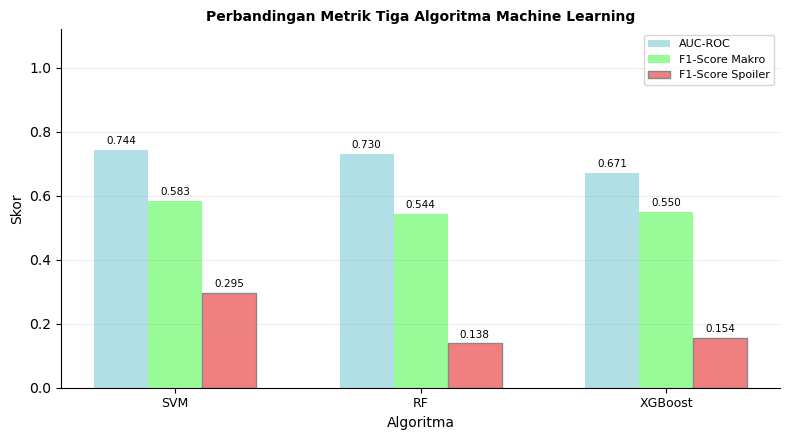

In [19]:
model_names = list(results.keys())
auc_values = [results[m]["auc_roc"] for m in model_names]
f1_macro = [results[m]["f1_macro"] for m in model_names]
f1_spoiler = [results[m]["f1_1"] for m in model_names]

x = np.arange(len(model_names))
width = 0.22
C1, C2, C3 = "powderblue", "palegreen", "lightcoral"

fig, ax = plt.subplots(figsize=(8, 4.5))
bars1 = ax.bar(x - width, auc_values, width, label="AUC-ROC", color=C1)
bars2 = ax.bar(x, f1_macro, width, label="F1-Score Makro", color=C2)
bars3 = ax.bar(x + width, f1_spoiler, width, label="F1-Score Spoiler", color=C3, edgecolor="#888888")

ax.set_xlabel("Algoritma", fontsize=10)
ax.set_ylabel("Skor", fontsize=10)
ax.set_title("Perbandingan Metrik Tiga Algoritma Machine Learning", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis="y", alpha=0.25, linewidth=0.7)
ax.spines[["top","right"]].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012, f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig("ml_perbandingan_metrik.png", dpi=300, bbox_inches="tight")
plt.show()

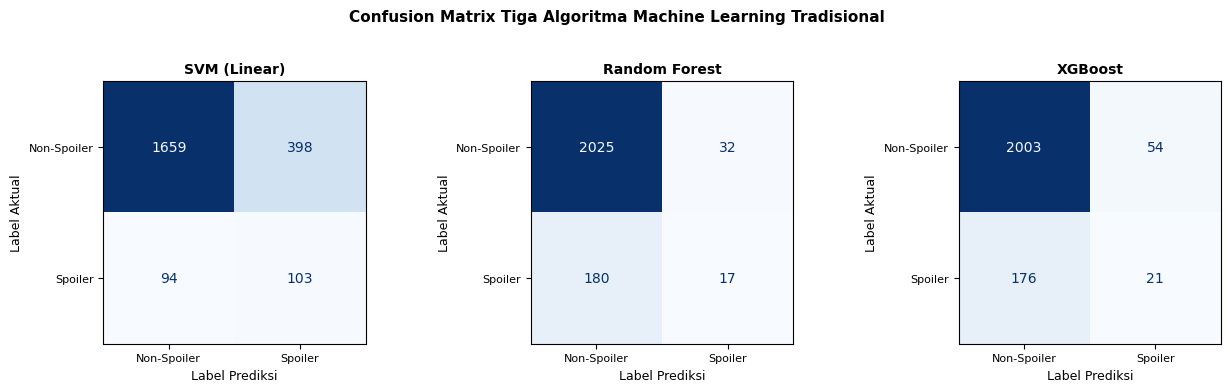

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

model_pred_pairs = [
  ("SVM (Linear)", predictions["SVM"]),
  ("Random Forest", predictions["RF"]),
  ("XGBoost", predictions["XGBoost"]),
]

for ax, (name, pred) in zip(axes, model_pred_pairs):
  cm = confusion_matrix(y_test, pred)
  disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spoiler", "Spoiler"]
  )
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(name, fontsize=10, fontweight="bold", pad=6)
  ax.set_xlabel("Label Prediksi", fontsize=9)
  ax.set_ylabel("Label Aktual", fontsize=9)
  ax.tick_params(labelsize=8)

plt.suptitle("Confusion Matrix Tiga Algoritma Machine Learning Tradisional", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ml_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

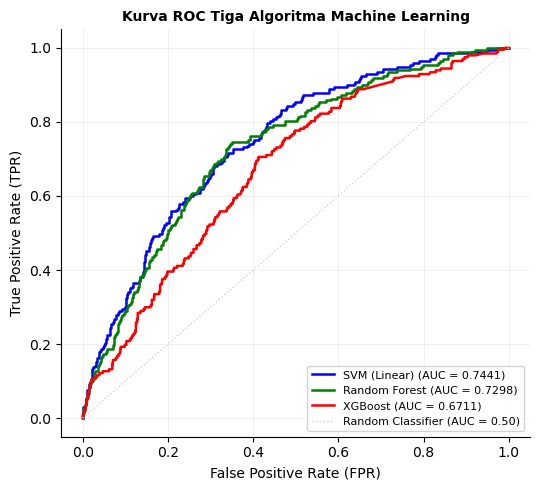

roc scores disimpan ke roc_scores_ml.pkl untuk digabung dengan roc dl nanti


In [23]:
# roc curve tiga algoritma ml
from sklearn.metrics import roc_curve

all_scores = {
  "SVM (Linear)": best_svm.decision_function(X_test_raw),
  "Random Forest": best_rf.predict_proba(X_test_raw)[:, 1],
  "XGBoost": best_xgb.predict_proba(X_test_raw)[:, 1],
}

COLORS_ROC = ["blue", "green", "red"]
STYLES = ["-", "-", "-"]

fig, ax = plt.subplots(figsize=(5.5, 5))
for (name, score), color, ls in zip(all_scores.items(), COLORS_ROC, STYLES):
    fpr, tpr, _ = roc_curve(y_test, score)
    auc_val = roc_auc_score(y_test, score)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", color=color, lw=1.8, ls=ls)

ax.plot([0,1],[0,1], color="lightgray", lw=1, ls=":", label="Random Classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate (FPR)", fontsize=10)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=10)
ax.set_title("Kurva ROC Tiga Algoritma Machine Learning", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("ml_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# simpan skor untuk roc curve gabungan di notebook bert
import pickle
roc_scores_ml = {
    "SVM (Linear)"  : best_svm.decision_function(X_test_raw).tolist(),
    "Random Forest" : best_rf.predict_proba(X_test_raw)[:, 1].tolist(),
    "XGBoost"       : best_xgb.predict_proba(X_test_raw)[:, 1].tolist(),
    "y_test"        : y_test.tolist()
}
with open("roc_scores_ml.pkl", "wb") as f:
    pickle.dump(roc_scores_ml, f)
print("roc scores disimpan ke roc_scores_ml.pkl untuk digabung dengan roc dl nanti")

## 10. Ringkasan Hasil

In [24]:
# model terbaik untuk setiap metrik
best_auc_model = max(results, key=lambda m: results[m]["auc_roc"]) # model dengan AUC tertinggi
best_f1_model = max(results, key=lambda m: results[m]["f1_1"]) # model dengan F1 spoiler tertinggi
best_rec_model = max(results, key=lambda m: results[m]["recall_1"]) # model dengan recall spoiler tertinggi

print("RINGKASAN HASIL ALGORITMA MACHINE LEARNING")
print(f"\nAlgoritma terbaik berdasarkan AUC-ROC: {best_auc_model} ({results[best_auc_model]['auc_roc']:.4f})")
print(f"Algoritma terbaik berdasarkan F1 spoiler: {best_f1_model} ({results[best_f1_model]['f1_1']:.4f})")
print(f"Algoritma terbaik berdasarkan recall spoiler: {best_rec_model} ({results[best_rec_model]['recall_1']:.4f})")

print("\nPerbandingan Final")
for model, r in results.items():
  print(f"\n{model}:")
  print(f"AUC-ROC         : {r['auc_roc']:.4f}")
  print(f"F1 spoiler      : {r['f1_1']:.4f}")
  print(f"Recall spoiler  : {r['recall_1']:.4f}")
  print(f"F1 macro        : {r['f1_macro']:.4f}")

RINGKASAN HASIL ALGORITMA MACHINE LEARNING

Algoritma terbaik berdasarkan AUC-ROC: SVM (0.7441)
Algoritma terbaik berdasarkan F1 spoiler: SVM (0.2951)
Algoritma terbaik berdasarkan recall spoiler: SVM (0.5228)

Perbandingan Final

SVM:
AUC-ROC         : 0.7441
F1 spoiler      : 0.2951
Recall spoiler  : 0.5228
F1 macro        : 0.5830

RF:
AUC-ROC         : 0.7298
F1 spoiler      : 0.1382
Recall spoiler  : 0.0863
F1 macro        : 0.5442

XGBoost:
AUC-ROC         : 0.6711
F1 spoiler      : 0.1544
Recall spoiler  : 0.1066
F1 macro        : 0.5501


Catatan Perubahan

**Mengapa Pipeline menggantikan TF-IDF standalone**  
TF-IDF yang di-fit di luar GridSearchCV menyebabkan data leakage: vocabulary terbentuk dari seluruh data latih sebelum cross-validation dimulai, sehingga setiap fold validasi sudah "terpengaruh" oleh distribusi kata dari fold training lainnya. Dengan Pipeline, TF-IDF di-fit ulang hanya pada data training di setiap fold, membuat evaluasi cross-validation menjadi valid.

**Handling imbalance dengan `class_weight='balanced'` dan `scale_pos_weight`**  
Pendekatan ini dipilih karena bekerja langsung pada fungsi loss tanpa mengubah distribusi data. SMOTE tidak dipakai karena interpolasi di ruang TF-IDF sparse tidak menghasilkan representasi teks yang bermakna secara linguistik. `scale_pos_weight` pada XGBoost sekarang ikut di-tune karena nilai optimal tidak selalu persis sama dengan rasio imbalance data.

**Keterbatasan**  
Model berbasis TF-IDF tidak memahami urutan kata. Kosakata yang sangat mirip antar kelas menjadi pembatas fundamental untuk semua model ML klasik, dan ini yang membuka motivasi untuk pendekatan deep learning dan BERT.

In [ ]:
'''
import os, joblib

EXPORT_DIR = "/content/drive/MyDrive/NLP_Kelompok3/models_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(vectorizer, os.path.join(EXPORT_DIR, "vectorizer.pkl"))
print("vectorizer.pkl tersimpan")

joblib.dump(best_svm, os.path.join(EXPORT_DIR, "svm_model.pkl"))
print("svm_model.pkl tersimpan")

joblib.dump(best_rf, os.path.join(EXPORT_DIR, "rf_model.pkl"))
print("rf_model.pkl tersimpan")

joblib.dump(best_xgb, os.path.join(EXPORT_DIR, "xgb_model.pkl"))
print("xgb_model.pkl tersimpan")
'''